In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# 1. Load dataset
df = pd.read_csv("filtered_features_s20.csv")

# 2. Set target column
target = "MagpieData mean GSbandgap"

# 3. Separate features and target
X = df.drop(columns=[target, "formula"], errors="ignore")
y = df[target]

# 4. Keep only numeric features
X = X.select_dtypes(include=np.number)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target:", target)

X shape: (1187, 84)
y shape: (1187,)
Target: MagpieData mean GSbandgap


In [7]:
# 2. Recursive Feature Elimination (RFE) with Ridge

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFE

# Remove rows where target is missing
valid = y.notna()

X_clean = X.loc[valid].copy()
y_clean = y.loc[valid].copy()

# Replace missing feature values with median
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_clean)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Ridge model
ridge = Ridge(alpha=1.0)

# Select top 20 features
rfe = RFE(
    estimator=ridge,
    n_features_to_select=20,
    step=1
)

# Fit RFE
X_rfe = rfe.fit_transform(X_scaled, y_clean)

print("Original features:", X.shape[1])
print("Selected features:", X_rfe.shape[1])
print("RFE completed successfully!")

Original features: 84
Selected features: 20
RFE completed successfully!


In [8]:
# Get the names of the top 20 selected features
top_features = X.columns[rfe.support_]
print(f"Top 20 features selected by RFE: \n{list(top_features)}")

Top 20 features selected by RFE: 
['MagpieData mean Number', 'MagpieData maximum MendeleevNumber', 'MagpieData minimum MeltingT', 'MagpieData mode MeltingT', 'MagpieData range Column', 'MagpieData mean Column', 'MagpieData avg_dev Column', 'MagpieData mean CovalentRadius', 'MagpieData mode CovalentRadius', 'MagpieData maximum Electronegativity', 'MagpieData mean Electronegativity', 'MagpieData mode NsValence', 'MagpieData minimum NpValence', 'MagpieData maximum NpValence', 'MagpieData mean NpValence', 'MagpieData mean NpUnfilled', 'MagpieData maximum GSbandgap', 'MagpieData mode GSbandgap', 'MagpieData minimum SpaceGroupNumber', 'MagpieData mean SpaceGroupNumber']


In [10]:
# 3. Random Forest Feature Importance

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Fit using the same cleaned target used in RFE
rf.fit(X_rfe, y_clean)

print("Random Forest training completed successfully!")

Random Forest training completed successfully!


In [11]:
# Extract and sort the importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

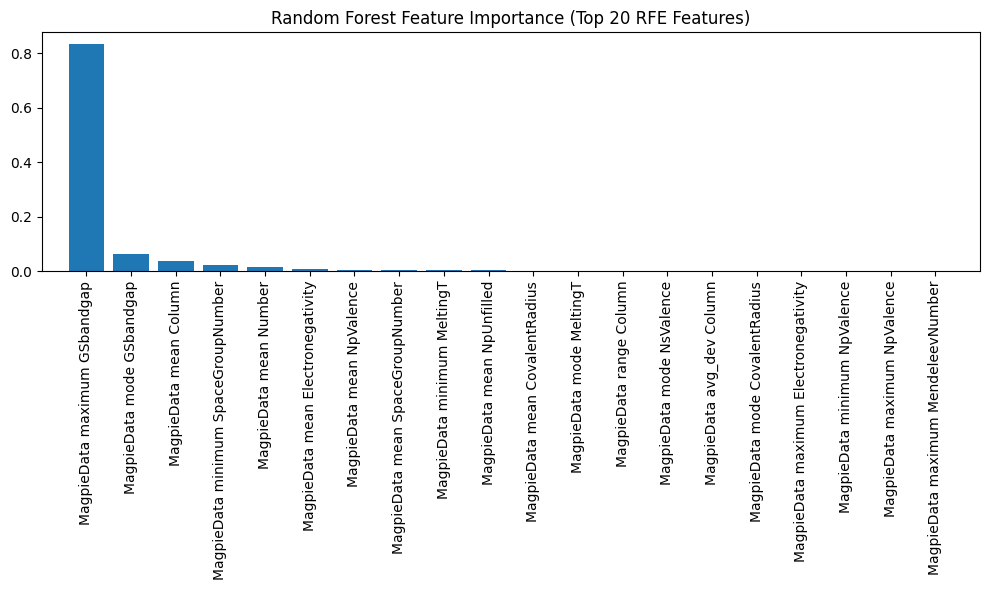

In [12]:
# 4. Preliminary Importance Bar Chart
plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance (Top 20 RFE Features)")
plt.bar(range(X_rfe.shape[1]), importances[indices], align="center")
plt.xticks(range(X_rfe.shape[1]), top_features[indices], rotation=90)
plt.xlim([-1, X_rfe.shape[1]])
plt.tight_layout()
plt.show()

In [16]:
# 5. Save the final curated dataset

target = "MagpieData mean GSbandgap"

# Get the 20 features selected by RFE
top_features = X.columns[rfe.support_]

# Create final dataset
df_curated = df[[target] + list(top_features)].copy()

# Save the dataset
df_curated.to_csv("curated_features_s21.csv", index=False)

print("Final curated feature set saved successfully!")
print("Shape:", df_curated.shape)
print("Selected features:", len(top_features))

Final curated feature set saved successfully!
Shape: (1187, 21)
Selected features: 20
